
📊 Variables con mayor diferencia promedio (MAE):

                                         MAE
sentimientos__valencia_general         0.229
sentimientos__gobernanza               0.209
confianza                              0.174
sentimientos__expectativa_macro_corto  0.122
sentimientos__expectativa_fin_corto    0.110
mercado__fx_usdars                     0.088
sentimientos__expectativa_macro_largo  0.083
mercado__actividad_economica           0.082
mercado__merval                        0.072
sentimientos__expectativa_fin_largo    0.071
mercado__bonos_soberanos               0.051
mercado__tasa_bcra                     0.024
calidad_fuente__score                  0.002

🔗 Correlación entre predicciones nano vs mini:

                                       correlacion
mercado__fx_usdars                        0.454928
sentimientos__gobernanza                  0.490901
sentimientos__expectativa_fin_corto       0.492415
mercado__merval                           0.522544
sentimientos__v

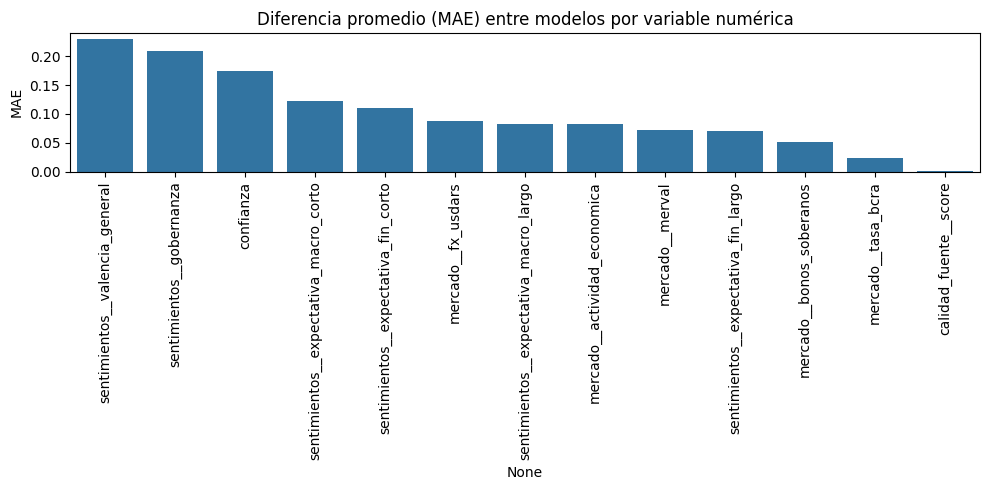

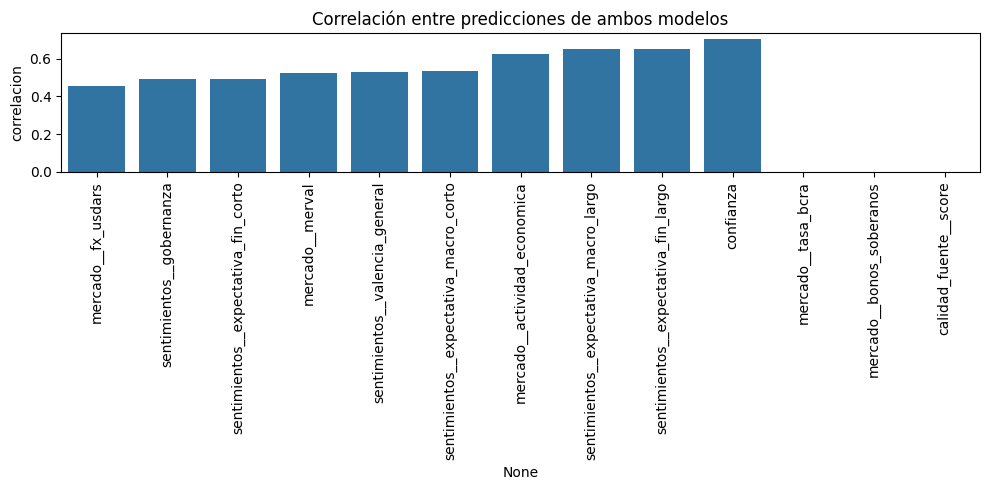

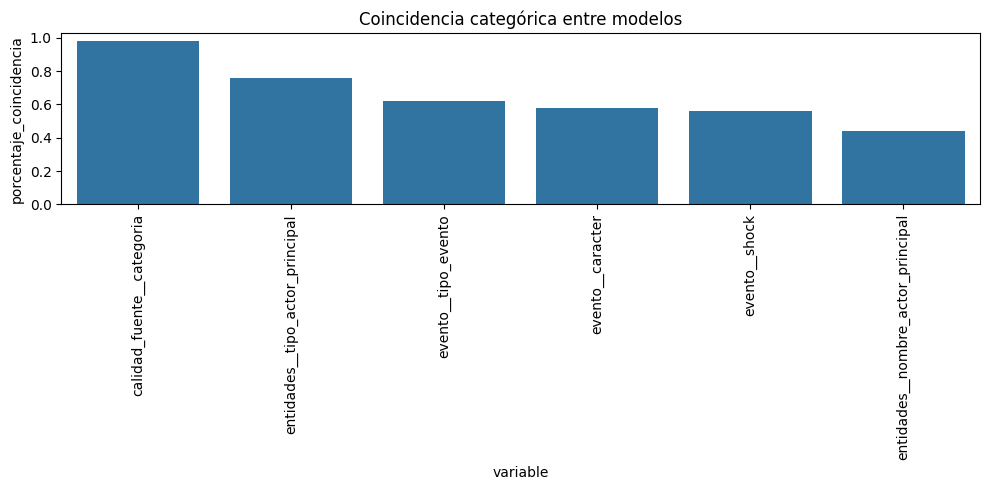


Resumen global:
- Promedio correlación numérica: nan
- Promedio MAE numérico: 0.101
- Promedio coincidencia categórica: 65.67%

📉 Sesgo promedio por variable (nano - mini):

                                       Diferencia media (nano - mini)
confianza                                                      -0.140
calidad_fuente__score                                          -0.002
mercado__tasa_bcra                                              0.000
mercado__fx_usdars                                              0.012
sentimientos__expectativa_macro_largo                           0.017
mercado__bonos_soberanos                                        0.019
sentimientos__expectativa_fin_largo                             0.023
mercado__actividad_economica                                    0.026
sentimientos__expectativa_fin_corto                             0.028
mercado__merval                                                 0.036
sentimientos__expectativa_macro_corto                  

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

# ==============================
# 1. Cargar los datos
# ==============================
df_nano = pd.read_csv("../df_sample50_gpt-5-nano.csv")
df_mini = pd.read_csv("../df_sample50_gpt-5-mini.csv")

# Alinear por URL o título
merge_on = "url" if "url" in df_nano.columns else "titulo"
df = pd.merge(df_nano, df_mini, on=merge_on, suffixes=("_nano", "_mini"))

# ==============================
# 2. Comparar variables numéricas
# ==============================
cols_num = [
    "confianza",
    "mercado__merval",
    "mercado__fx_usdars",
    "mercado__tasa_bcra",
    "mercado__bonos_soberanos",
    "mercado__actividad_economica",
    "sentimientos__valencia_general",
    "sentimientos__gobernanza",
    "sentimientos__expectativa_macro_corto",
    "sentimientos__expectativa_macro_largo",
    "sentimientos__expectativa_fin_corto",
    "sentimientos__expectativa_fin_largo",
    "calidad_fuente__score",
]

# Calcular diferencias
diffs = {}
for col in cols_num:
    if col + "_nano" in df.columns and col + "_mini" in df.columns:
        diffs[col] = mean_absolute_error(df[col + "_mini"], df[col + "_nano"])

# Crear ranking de diferencias
df_diff = pd.DataFrame.from_dict(diffs, orient="index", columns=["MAE"]).sort_values("MAE", ascending=False)
print("\n📊 Variables con mayor diferencia promedio (MAE):\n")
print(df_diff)

# ==============================
# 3. Correlaciones entre modelos
# ==============================
corrs = {}
for col in cols_num:
    if col + "_nano" in df.columns and col + "_mini" in df.columns:
        corrs[col] = df[[col + "_nano", col + "_mini"]].corr().iloc[0, 1]

df_corr = pd.DataFrame.from_dict(corrs, orient="index", columns=["correlacion"]).sort_values("correlacion")
print("\n🔗 Correlación entre predicciones nano vs mini:\n")
print(df_corr)

# ==============================
# 4. Comparar variables categóricas
# ==============================
cols_cat = [
    "entidades__tipo_actor_principal",
    "entidades__nombre_actor_principal",
    "evento__tipo_evento",
    "evento__shock",
    "evento__caracter",
    "calidad_fuente__categoria",
]

cat_results = []
for col in cols_cat:
    if col + "_nano" in df.columns and col + "_mini" in df.columns:
        iguales = (df[col + "_nano"] == df[col + "_mini"]).mean()
        cat_results.append((col, iguales))

df_cat = pd.DataFrame(cat_results, columns=["variable", "porcentaje_coincidencia"]).sort_values("porcentaje_coincidencia", ascending=False)
print("\n🧩 Coincidencia categórica entre modelos:\n")
print(df_cat)

# ==============================
# 5. Visualizaciones
# ==============================
plt.figure(figsize=(10, 5))
sns.barplot(x=df_diff.index, y=df_diff["MAE"])
plt.xticks(rotation=90)
plt.title("Diferencia promedio (MAE) entre modelos por variable numérica")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x=df_corr.index, y=df_corr["correlacion"])
plt.xticks(rotation=90)
plt.title("Correlación entre predicciones de ambos modelos")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x="variable", y="porcentaje_coincidencia", data=df_cat)
plt.xticks(rotation=90)
plt.title("Coincidencia categórica entre modelos")
plt.tight_layout()
plt.show()

# ==============================
# 6. Evaluación global
# ==============================
print("\nResumen global:")
print(f"- Promedio correlación numérica: {np.mean(list(corrs.values())):.3f}")
print(f"- Promedio MAE numérico: {np.mean(list(diffs.values())):.3f}")
print(f"- Promedio coincidencia categórica: {df_cat['porcentaje_coincidencia'].mean():.2%}")

# ==============================
# 7. Detección de sesgos
# ==============================
# Ver si un modelo tiende a valores más altos o bajos
bias = {}
for col in cols_num:
    if col + "_nano" in df.columns and col + "_mini" in df.columns:
        bias[col] = (df[col + "_nano"].mean() - df[col + "_mini"].mean())

df_bias = pd.DataFrame.from_dict(bias, orient="index", columns=["Diferencia media (nano - mini)"]).sort_values("Diferencia media (nano - mini)")
print("\n📉 Sesgo promedio por variable (nano - mini):\n")
print(df_bias)


In [4]:
# ==============================
# 8. Ejemplos de diferencias grandes
# ==============================

# Seleccionar una variable principal para medir diferencia (puede ser confianza o valencia general)
col_base = "confianza"

# Calcular la diferencia absoluta
df["diff_confianza"] = abs(df[f"{col_base}_nano"] - df[f"{col_base}_mini"])

# Top 10 noticias con mayor diferencia de confianza
top_confianza = df.sort_values("diff_confianza", ascending=False).head(10)[
    ["fecha_mini", "diario_mini", "titulo_mini", f"{col_base}_nano", f"{col_base}_mini", "diff_confianza", "url"]
]
print("\n📰 Noticias con mayor diferencia en confianza:\n")
display(top_confianza)

# ==============================
# 9. Otras variables numéricas con alta diferencia
# ==============================
# Promedio de diferencia entre todas las variables numéricas
df["diff_media"] = df[[f"{c}_nano" for c in cols_num if f"{c}_mini" in df.columns]].sub(
    df[[f"{c}_mini" for c in cols_num if f"{c}_nano" in df.columns]].values
).abs().mean(axis=1)

top_global = df.sort_values("diff_media", ascending=False).head(10)[
    ["fecha_mini", "diario_mini", "titulo_mini", "diff_media", "url"]
]
print("\n⚖️ Noticias con mayor diferencia global entre modelos:\n")
display(top_global)

# ==============================
# 10. Ejemplos de diferencias categóricas
# ==============================
# Ver casos donde cambió el tipo de evento
mask_evento = df["evento__tipo_evento_nano"] != df["evento__tipo_evento_mini"]
diff_evento = df[mask_evento][
    ["fecha_mini", "diario_mini", "titulo_mini", "evento__tipo_evento_nano", "evento__tipo_evento_mini", "url"]
].head(10)

print("\n🎭 Ejemplos donde difiere el tipo de evento:\n")
display(diff_evento)



📰 Noticias con mayor diferencia en confianza:



,fecha_mini,diario_mini,titulo_mini,confianza_nano,confianza_mini,diff_confianza,url
35,2025-04-09,La Nación,Axel Kicillof le envió un mensaje conciliador ...,0.20,0.85,0.65,https://www.lanacion.com.ar/politica/axel-kici...
13,2025-03-12,Ámbito Financiero,El Gobierno confía en que el DNU por el acuerd...,0.20,0.80,0.60,https://www.ambito.com/politica/el-gobierno-co...
39,2025-02-15,Ámbito Financiero,"Tras el escándalo cripto, Javier Milei se ases...",0.20,0.80,0.60,https://www.ambito.com/politica/tras-el-escand...
3,2025-04-07,Ámbito Financiero,Peligra en Diputados la sesión por $LIBRA: la ...,0.25,0.85,0.60,https://www.ambito.com/politica/peligra-diputa...
26,2025-01-13,Ámbito Financiero,"Charlas de quincho: toque de campana, con nego...",0.25,0.70,0.45,https://www.ambito.com/politica/charlas-quinch...
20,2025-04-03,Pagina 12,Renuncia con denuncia por vaciamiento del INTA,0.25,0.70,0.45,https://www.pagina12.com.ar/815234-renuncia-co...
30,2025-03-23,La Nación,Se retiraron de muy buenas profesiones e invir...,0.70,0.30,0.40,https://www.lanacion.com.ar/economia/campo/est...
5,2025-01-14,La Nación,"Milei ganó el ""Premio Nobel Judío"" por su apoy...",0.65,0.30,0.35,https://www.lanacion.com.ar/politica/milei-gan...
38,2025-01-27,Clarín,Baja de las retenciones al campo: la condición...,0.60,0.90,0.30,https://www.clarin.com/economia/publican-decre...
0,2025-04-15,Ámbito Financiero,El gobierno de Javier Milei eliminó el RUCA y ...,0.65,0.90,0.25,https://www.ambito.com/economia/el-gobierno-ja...



⚖️ Noticias con mayor diferencia global entre modelos:



,fecha_mini,diario_mini,titulo_mini,diff_media,url
35,2025-04-09,La Nación,Axel Kicillof le envió un mensaje conciliador ...,0.303846,https://www.lanacion.com.ar/politica/axel-kici...
18,2025-03-16,Ámbito Financiero,Dólar y la pregunta del mercado: ¿con qué pesos?,0.276923,https://www.ambito.com/opiniones/dolar-y-la-pr...
7,2025-03-25,Ámbito Financiero,DNU sin necesidad ni urgencia,0.257692,https://www.ambito.com/opiniones/dnu-necesidad...
20,2025-04-03,Pagina 12,Renuncia con denuncia por vaciamiento del INTA,0.250000,https://www.pagina12.com.ar/815234-renuncia-co...
16,2025-02-09,Ámbito Financiero,Los primeros pasos de Donald Trump: el fuerte ...,0.223077,https://www.ambito.com/opiniones/los-primeros-...
13,2025-03-12,Ámbito Financiero,El Gobierno confía en que el DNU por el acuerd...,0.215385,https://www.ambito.com/politica/el-gobierno-co...
34,2025-01-05,Ámbito Financiero,"Inflación, dólar y salarios: las consultoras a...",0.203846,https://www.ambito.com/economia/inflacion-dola...
45,2025-01-08,La Nación,Un empresario dijo que “incomoda” el achique d...,0.196154,https://www.lanacion.com.ar/economia/el-dueno-...
11,2025-04-15,Ámbito Financiero,EEUU descarta una línea de crédito adicional p...,0.196154,https://www.ambito.com/economia/eeuu-descarta-...
30,2025-03-23,La Nación,Se retiraron de muy buenas profesiones e invir...,0.192308,https://www.lanacion.com.ar/economia/campo/est...



🎭 Ejemplos donde difiere el tipo de evento:



,fecha_mini,diario_mini,titulo_mini,evento__tipo_evento_nano,evento__tipo_evento_mini,url
3,2025-04-07,Ámbito Financiero,Peligra en Diputados la sesión por $LIBRA: la ...,desconocido,otro,https://www.ambito.com/politica/peligra-diputa...
4,2025-01-29,La Nación,La baja de retenciones podría ayudar a contene...,regulatorio,fiscal,https://www.lanacion.com.ar/economia/esquema-8...
7,2025-03-25,Ámbito Financiero,DNU sin necesidad ni urgencia,regulatorio,externo,https://www.ambito.com/opiniones/dnu-necesidad...
13,2025-03-12,Ámbito Financiero,El Gobierno confía en que el DNU por el acuerd...,regulatorio,fiscal,https://www.ambito.com/politica/el-gobierno-co...
14,2025-03-25,Ámbito Financiero,"En medio de la paralización, el secretario de ...",regulatorio,fiscal,https://www.ambito.com/politica/en-medio-la-pa...
16,2025-02-09,Ámbito Financiero,Los primeros pasos de Donald Trump: el fuerte ...,regulatorio,externo,https://www.ambito.com/opiniones/los-primeros-...
19,2025-03-13,La Nación,"Villarruel dio un mensaje de apoyo al campo, a...",regulatorio,desconocido,https://www.lanacion.com.ar/economia/campo/el-...
20,2025-04-03,Pagina 12,Renuncia con denuncia por vaciamiento del INTA,desconocido,regulatorio,https://www.pagina12.com.ar/815234-renuncia-co...
23,2025-03-12,La Nación,Bahía Blanca: ¡Apareció un cisne negro!,desconocido,externo,https://www.lanacion.com.ar/economia/bahia-bla...
26,2025-01-13,Ámbito Financiero,"Charlas de quincho: toque de campana, con nego...",desconocido,regulatorio,https://www.ambito.com/politica/charlas-quinch...


📉 Cantidad de 'desconocido' o NaN por modelo y variable:



,variable,desconocido_nano,desconocido_mini,porc_nano,porc_mini
8,evento__horizonte_dias,42,41,84.0,82.0
5,evento__tipo_evento,18,16,36.0,32.0
6,evento__shock,16,9,32.0,18.0
7,evento__caracter,16,18,32.0,36.0
0,entidades__tipo_actor_principal,9,4,18.0,8.0
1,entidades__nombre_actor_principal,6,2,12.0,4.0
2,entidades__empresas_mencionadas,0,0,0.0,0.0
3,entidades__tickers_mencionados,0,0,0.0,0.0
4,entidades__sectores_mencionados,0,0,0.0,0.0
9,mercado__merval,0,0,0.0,0.0


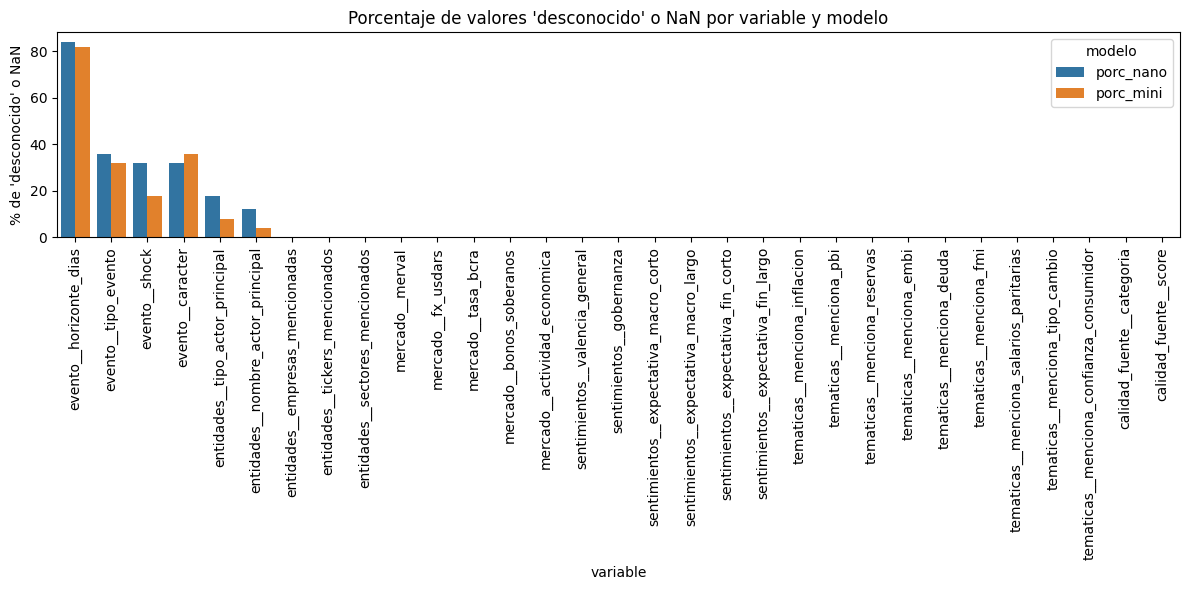

In [5]:
# ==============================
# 12. Conteo de "desconocido" o NaN por modelo y variable
# ==============================

variables = [
    "entidades__tipo_actor_principal",
    "entidades__nombre_actor_principal",
    "entidades__empresas_mencionadas",
    "entidades__tickers_mencionados",
    "entidades__sectores_mencionados",
    "evento__tipo_evento",
    "evento__shock",
    "evento__caracter",
    "evento__horizonte_dias",
    "mercado__merval",
    "mercado__fx_usdars",
    "mercado__tasa_bcra",
    "mercado__bonos_soberanos",
    "mercado__actividad_economica",
    "sentimientos__valencia_general",
    "sentimientos__gobernanza",
    "sentimientos__expectativa_macro_corto",
    "sentimientos__expectativa_macro_largo",
    "sentimientos__expectativa_fin_corto",
    "sentimientos__expectativa_fin_largo",
    "tematicas__menciona_inflacion",
    "tematicas__menciona_pbi",
    "tematicas__menciona_reservas",
    "tematicas__menciona_embi",
    "tematicas__menciona_deuda",
    "tematicas__menciona_fmi",
    "tematicas__menciona_salarios_paritarias",
    "tematicas__menciona_tipo_cambio",
    "tematicas__menciona_confianza_consumidor",
    "calidad_fuente__categoria",
    "calidad_fuente__score"
]

# Función auxiliar para contar desconocidos o nulos
def contar_desconocidos(df, col):
    total = len(df)
    c_nano = 0
    c_mini = 0
    if f"{col}_nano" in df.columns:
        serie = df[f"{col}_nano"].astype(str).str.lower()
        c_nano = ((serie == "desconocido") | (serie == "nan") | (df[f"{col}_nano"].isna())).sum()
    if f"{col}_mini" in df.columns:
        serie = df[f"{col}_mini"].astype(str).str.lower()
        c_mini = ((serie == "desconocido") | (serie == "nan") | (df[f"{col}_mini"].isna())).sum()
    return c_nano, c_mini, total

# Crear dataframe resumen
stats = []
for col in variables:
    c_nano, c_mini, total = contar_desconocidos(df, col)
    stats.append({
        "variable": col,
        "desconocido_nano": c_nano,
        "desconocido_mini": c_mini,
        "porc_nano": c_nano / total * 100,
        "porc_mini": c_mini / total * 100
    })

df_desc = pd.DataFrame(stats).sort_values("porc_nano", ascending=False)

print("📉 Cantidad de 'desconocido' o NaN por modelo y variable:\n")
display(df_desc)

# ==============================
# 13. Visualización comparativa
# ==============================
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
df_melt = df_desc.melt(id_vars="variable", value_vars=["porc_nano", "porc_mini"], 
                       var_name="modelo", value_name="porcentaje")
sns.barplot(data=df_melt, x="variable", y="porcentaje", hue="modelo")
plt.xticks(rotation=90)
plt.ylabel("% de 'desconocido' o NaN")
plt.title("Porcentaje de valores 'desconocido' o NaN por variable y modelo")
plt.tight_layout()
plt.show()


In [13]:
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd
import ast
import json

# =========================================================
# CONFIGURACIÓN DE VARIABLES POR TIPO
# =========================================================
numericas = [
    "confianza",
    "mercado__merval", "mercado__fx_usdars", "mercado__tasa_bcra",
    "mercado__bonos_soberanos", "mercado__actividad_economica",
    "sentimientos__valencia_general", "sentimientos__gobernanza",
    "sentimientos__expectativa_macro_corto", "sentimientos__expectativa_macro_largo",
    "sentimientos__expectativa_fin_corto", "sentimientos__expectativa_fin_largo",
    "calidad_fuente__score"
]

booleanas = [
    "tematicas__menciona_inflacion", "tematicas__menciona_pbi",
    "tematicas__menciona_reservas", "tematicas__menciona_embi",
    "tematicas__menciona_deuda", "tematicas__menciona_fmi",
    "tematicas__menciona_salarios_paritarias", "tematicas__menciona_tipo_cambio",
    "tematicas__menciona_confianza_consumidor"
]

categoricas = [
    "entidades__tipo_actor_principal", "entidades__nombre_actor_principal",
    "evento__tipo_evento", "evento__shock", "evento__caracter",
    "calidad_fuente__categoria"
]

listas = [
    "entidades__empresas_mencionadas", "entidades__tickers_mencionados",
    "entidades__sectores_mencionados"
]

# =========================================================
# FUNCIÓN GENERAL DE COMPARACIÓN
# =========================================================
def comparar_variable(df, col):
    """Compara una variable según su tipo de dato."""
    col_nano, col_mini = f"{col}_nano", f"{col}_mini"
    if col_nano not in df.columns or col_mini not in df.columns:
        return np.nan, np.nan, np.nan, np.nan, "sin datos"

    serie_nano, serie_mini = df[col_nano], df[col_mini]

    # Desconocidos o nulos
    n_nano = serie_nano.isna().sum() + (serie_nano.astype(str).str.lower() == "desconocido").sum()
    n_mini = serie_mini.isna().sum() + (serie_mini.astype(str).str.lower() == "desconocido").sum()
    total = len(df)

    porc_nano = n_nano / total * 100
    porc_mini = n_mini / total * 100
    diff_perc = porc_nano - porc_mini

    # -----------------------------------------------------
    # 1️⃣ Numéricas → MAE
    # -----------------------------------------------------
    if col in numericas:
        a = pd.to_numeric(serie_nano, errors="coerce")
        b = pd.to_numeric(serie_mini, errors="coerce")
        mask = (~a.isna()) & (~b.isna())
        mae = mean_absolute_error(a[mask], b[mask]) if mask.sum() > 0 else np.nan
        return porc_nano, porc_mini, diff_perc, mae, "MAE"

    # -----------------------------------------------------
    # 2️⃣ Booleanas → % de veces distintas
    # -----------------------------------------------------
    if col in booleanas:
        a = serie_nano.astype(str).str.lower().replace({"true": True, "false": False})
        b = serie_mini.astype(str).str.lower().replace({"true": True, "false": False})
        mask = (~a.isna()) & (~b.isna())
        diff_rate = (a[mask] != b[mask]).mean() * 100 if mask.sum() > 0 else np.nan
        return porc_nano, porc_mini, diff_perc, diff_rate, "% distinto"

    # -----------------------------------------------------
    # 3️⃣ Categóricas → % de veces distintas
    # -----------------------------------------------------
    if col in categoricas:
        mask = (~serie_nano.isna()) & (~serie_mini.isna())
        diff_rate = (serie_nano[mask] != serie_mini[mask]).mean() * 100 if mask.sum() > 0 else np.nan
        return porc_nano, porc_mini, diff_perc, diff_rate, "% distinto"

    # -----------------------------------------------------
    # 4️⃣ Listas → % de elementos distintos promedio (corregido)
    # -----------------------------------------------------
    if col in listas:
        def to_list(x):
            """Convierte strings, listas o NaN en listas Python limpias."""
            if isinstance(x, list):
                return [str(i).strip().lower() for i in x if i not in [None, "", "nan"]]
            if pd.isna(x) or str(x).strip().lower() in ["nan", "none", "desconocido", ""]:
                return []
            s = str(x).strip()
            try:
                # si es tipo "['a','b']" o "[\"a\", \"b\"]"
                if s.startswith("[") and s.endswith("]"):
                    return [str(i).strip().lower() for i in ast.literal_eval(s)]
                # si viene separada por comas: "a, b, c"
                elif "," in s:
                    return [i.strip().lower() for i in s.split(",") if i.strip()]
                else:
                    return [s.lower()]
            except Exception:
                return [s.lower()]

        lista_nano = serie_nano.apply(to_list)
        lista_mini = serie_mini.apply(to_list)

        diffs = []
        for a, b in zip(lista_nano, lista_mini):
            sa, sb = set(a), set(b)
            if len(sa) == 0 and len(sb) == 0:
                diffs.append(0)
            else:
                diffs.append(len(sa.symmetric_difference(sb)) / max(len(sa.union(sb)), 1))

        diff_rate = np.nanmean(diffs) * 100 if len(diffs) > 0 else np.nan
        return porc_nano, porc_mini, diff_perc, diff_rate, "% distinto en lista"

    return porc_nano, porc_mini, diff_perc, np.nan, "sin datos"


# =========================================================
# APLICAR A TODAS LAS VARIABLES
# =========================================================
variables = numericas + booleanas + categoricas + listas
rows = []
for col in variables:
    porc_nano, porc_mini, diff_perc, metric, tipo_metric = comparar_variable(df, col)
    rows.append({
        "variable": col,
        "tipo": (
            "numérica" if col in numericas else
            "booleana" if col in booleanas else
            "categórica" if col in categoricas else
            "lista"
        ),
        "%_desconocido_nano": porc_nano,
        "%_desconocido_mini": porc_mini,
        "dif_%": diff_perc,
        "metric": metric,
        "tipo_metrica": tipo_metric
    })

df_eval = pd.DataFrame(rows).sort_values(["tipo", "variable"])

display(df_eval.style.format({
    "%_desconocido_nano": "{:.1f}%",
    "%_desconocido_mini": "{:.1f}%",
    "dif_%": "{:+.1f}%",
    "metric": "{:.3f}"
}))


/tmp/ipykernel_8177/2427615774.py:73: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  a = serie_nano.astype(str).str.lower().replace({"true": True, "false": False})
/tmp/ipykernel_8177/2427615774.py:74: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  b = serie_mini.astype(str).str.lower().replace({"true": True, "false": False})
/tmp/ipykernel_8177/2427615774.py:73: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(co

,variable,tipo,%_desconocido_nano,%_desconocido_mini,dif_%,metric,tipo_metrica
21,tematicas__menciona_confianza_consumidor,booleana,0.0%,0.0%,+0.0%,0.000,% distinto
17,tematicas__menciona_deuda,booleana,0.0%,0.0%,+0.0%,4.000,% distinto
16,tematicas__menciona_embi,booleana,0.0%,0.0%,+0.0%,2.000,% distinto
18,tematicas__menciona_fmi,booleana,0.0%,0.0%,+0.0%,0.000,% distinto
13,tematicas__menciona_inflacion,booleana,0.0%,0.0%,+0.0%,2.000,% distinto
14,tematicas__menciona_pbi,booleana,0.0%,0.0%,+0.0%,0.000,% distinto
15,tematicas__menciona_reservas,booleana,0.0%,0.0%,+0.0%,0.000,% distinto
19,tematicas__menciona_salarios_paritarias,booleana,0.0%,0.0%,+0.0%,2.000,% distinto
20,tematicas__menciona_tipo_cambio,booleana,0.0%,0.0%,+0.0%,10.000,% distinto
27,calidad_fuente__categoria,categórica,0.0%,0.0%,+0.0%,2.000,% distinto


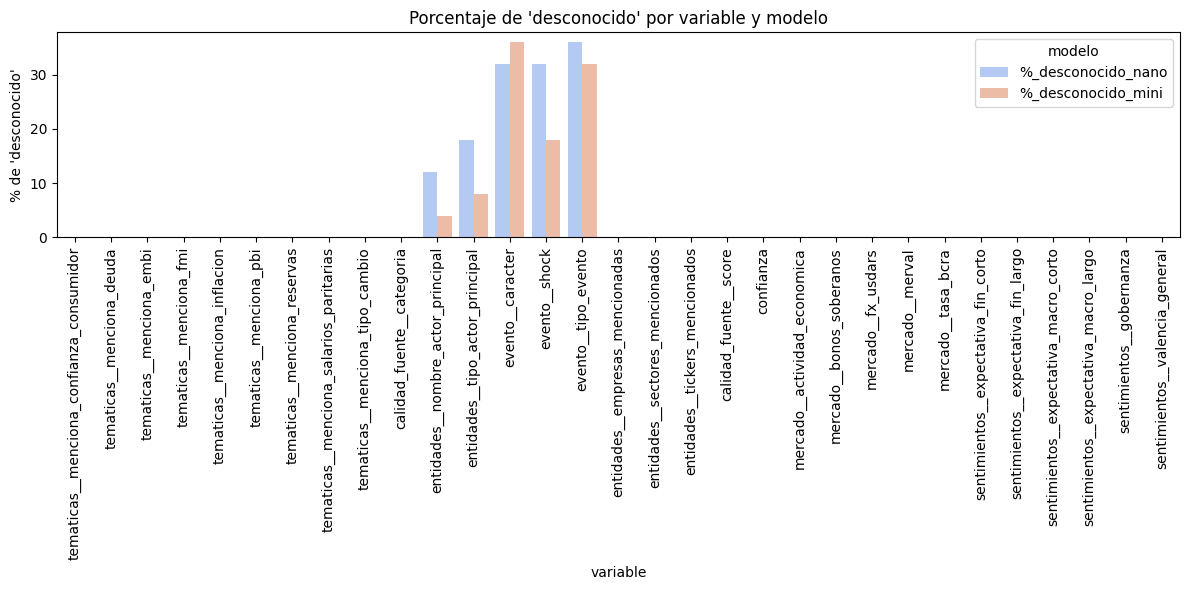

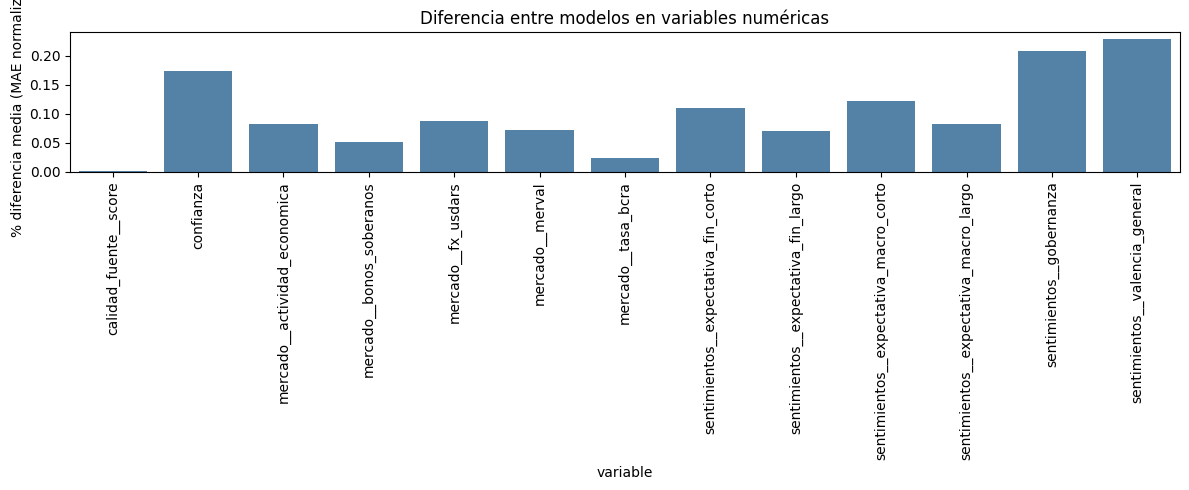

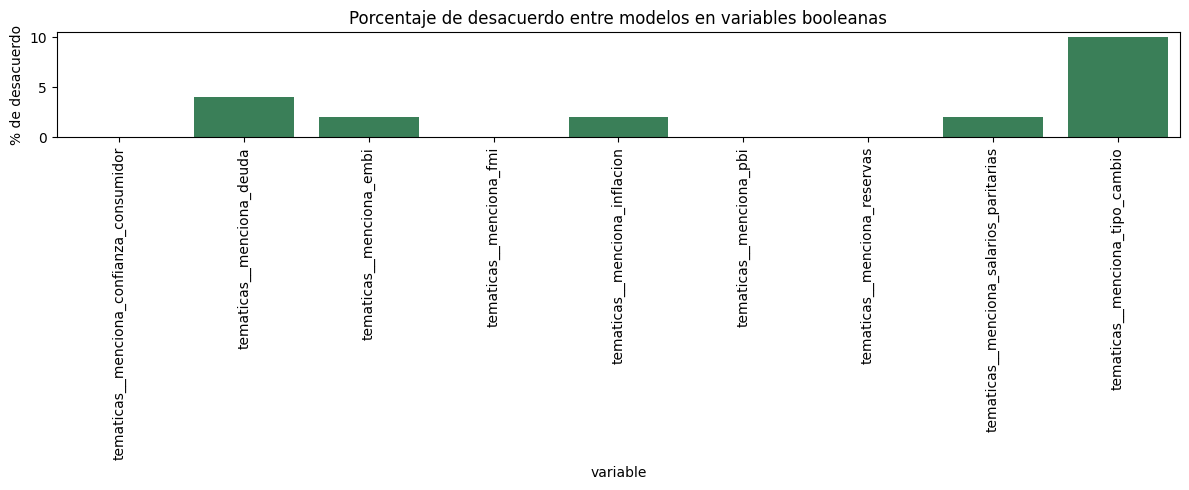

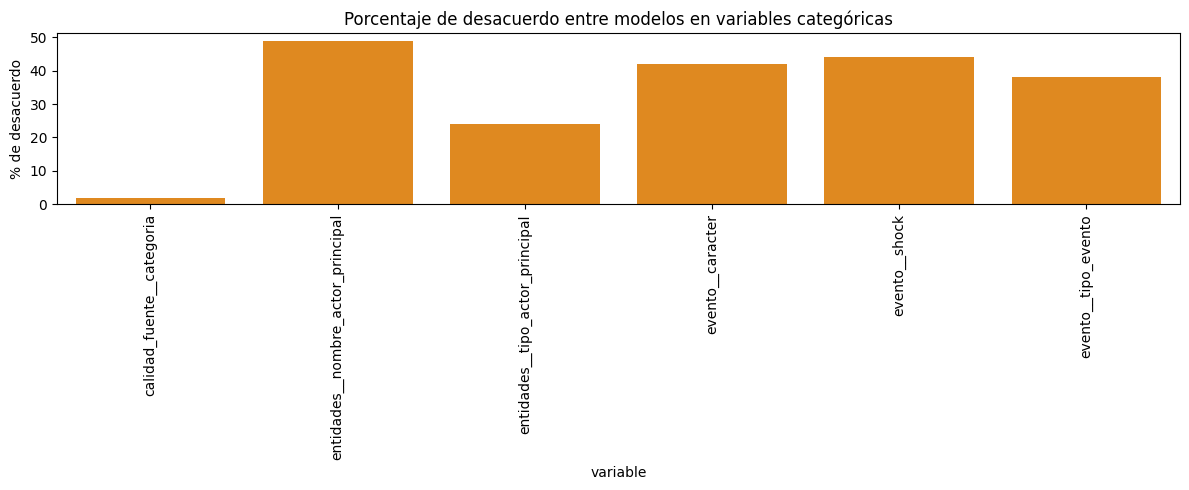

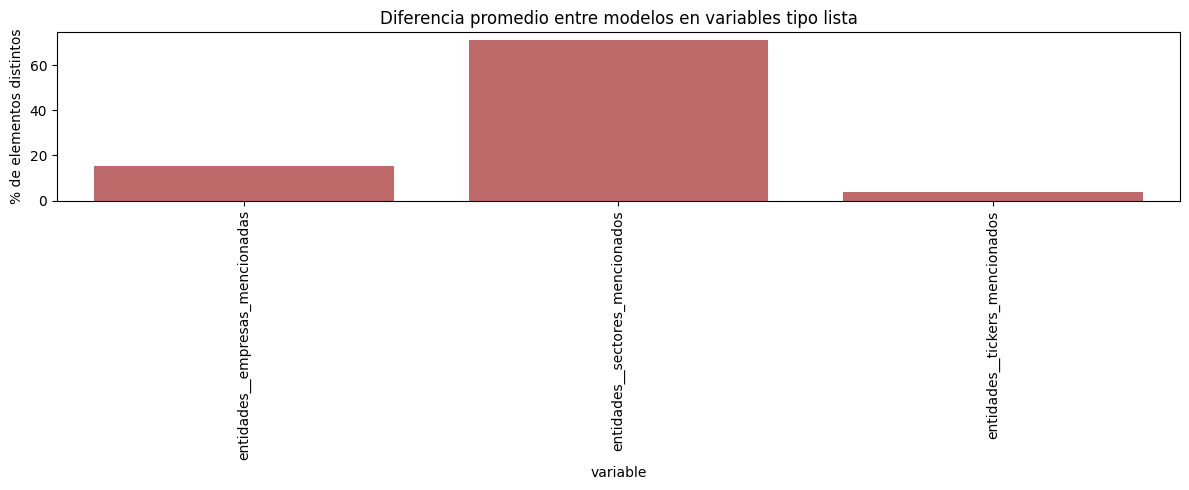

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================
# GRAFICO 1 - Desconocidos por modelo
# ==============================================
plt.figure(figsize=(12, 6))
df_melt_descon = df_eval.melt(
    id_vars=["variable"],
    value_vars=["%_desconocido_nano", "%_desconocido_mini"],
    var_name="modelo",
    value_name="porcentaje"
)

sns.barplot(data=df_melt_descon, x="variable", y="porcentaje", hue="modelo", palette="coolwarm")
plt.xticks(rotation=90)
plt.ylabel("% de 'desconocido'")
plt.title("Porcentaje de 'desconocido' por variable y modelo")
plt.tight_layout()
plt.show()

# ==============================================
# GRAFICOS 2–4 - Métricas de diferencia por tipo
# ==============================================
# Convertimos todas las métricas a porcentaje (ya lo están si normalizaste el MAE)
plt.figure(figsize=(12, 5))
sns.barplot(
    data=df_eval[df_eval["tipo"] == "numérica"],
    x="variable", y="metric", color="steelblue"
)
plt.xticks(rotation=90)
plt.ylabel("% diferencia media (MAE normalizado)")
plt.title("Diferencia entre modelos en variables numéricas")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(
    data=df_eval[df_eval["tipo"] == "booleana"],
    x="variable", y="metric", color="seagreen"
)
plt.xticks(rotation=90)
plt.ylabel("% de desacuerdo")
plt.title("Porcentaje de desacuerdo entre modelos en variables booleanas")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(
    data=df_eval[df_eval["tipo"] == "categórica"],
    x="variable", y="metric", color="darkorange"
)
plt.xticks(rotation=90)
plt.ylabel("% de desacuerdo")
plt.title("Porcentaje de desacuerdo entre modelos en variables categóricas")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(
    data=df_eval[df_eval["tipo"] == "lista"],
    x="variable", y="metric", color="indianred"
)
plt.xticks(rotation=90)
plt.ylabel("% de elementos distintos")
plt.title("Diferencia promedio entre modelos en variables tipo lista")
plt.tight_layout()
plt.show()


In [12]:
# ==============================
# EJEMPLOS DE ENTIDADES_SECTORES_MENCIONADOS (corregido)
# ==============================

import ast, json

col = "entidades__sectores_mencionados"

def to_list(x):
    """Convierte strings, listas o NaN a lista Python limpia."""
    if isinstance(x, list):
        return [str(i).strip() for i in x if i not in [None, "", "nan"]]
    if pd.isna(x) or str(x).strip().lower() in ["nan", "none", "desconocido", ""]:
        return []
    s = str(x).strip()
    try:
        # Si es JSON válido o lista Python
        if s.startswith("[") and s.endswith("]"):
            return [str(i).strip() for i in ast.literal_eval(s)]
        else:
            # caso separado por comas, sin []
            return [i.strip() for i in s.split(",") if i.strip()]
    except Exception:
        return [s]

# Convertir a listas reales
df[f"{col}_nano"] = df[f"{col}_nano"].apply(to_list)
df[f"{col}_mini"] = df[f"{col}_mini"].apply(to_list)

# Calcular diferencias entre los modelos
def diferencia(a, b):
    sa, sb = set(a), set(b)
    return {
        "coinciden": sorted(sa & sb),
        "solo_en_nano": sorted(sa - sb),
        "solo_en_mini": sorted(sb - sa),
        "n_dif": len(sa.symmetric_difference(sb))
    }

df["diff_detalle"] = [diferencia(a, b) for a, b in zip(df[f"{col}_nano"], df[f"{col}_mini"])]
df["n_dif_sectores"] = df["diff_detalle"].apply(lambda d: d["n_dif"])

# Mostrar las 5 noticias con mayor diferencia
top_diff = df.sort_values("n_dif_sectores", ascending=False).head(5)

for i, row in top_diff.iterrows():
    print("──────────────────────────────────────────────")
    print(f"📰  {row.get('titulo_mini', row.get('titulo_nano', ''))}")
    print(f"URL: {row.get('url', '')}")
    print(f"Fecha: {row.get('fecha_mini', row.get('fecha_nano', ''))}")
    print(f"Diario: {row.get('diario_mini', row.get('diario_nano', ''))}")
    print()
    print("🧠 Modelo MINI →", row[f"{col}_mini"])
    print("⚙️  Modelo NANO →", row[f"{col}_nano"])
    print()
    print("🔍 Detalle de diferencia:")
    print("  - Coinciden:", row["diff_detalle"]["coinciden"])
    print("  - Solo en MINI:", row["diff_detalle"]["solo_en_mini"])
    print("  - Solo en NANO:", row["diff_detalle"]["solo_en_nano"])
    print()


──────────────────────────────────────────────
📰  Los primeros pasos de Donald Trump: el fuerte foco en las tarifas abre incertidumbre en los mercados
URL: https://www.ambito.com/opiniones/los-primeros-pasos-donald-trump-el-fuerte-foco-las-tarifas-abre-incertidumbre-los-mercados-n6111485
Fecha: 2025-02-09
Diario: Ámbito Financiero

🧠 Modelo MINI → ['tecnología', 'consumo discrecional', 'automotriz', 'energía', 'industrial', 'financiero']
⚙️  Modelo NANO → ['tecnológico', 'consumo discrecional', 'hardware tecnológico', 'automóviles y componentes', 'industria']

🔍 Detalle de diferencia:
  - Coinciden: ['consumo discrecional']
  - Solo en MINI: ['automotriz', 'energía', 'financiero', 'industrial', 'tecnología']
  - Solo en NANO: ['automóviles y componentes', 'hardware tecnológico', 'industria', 'tecnológico']

──────────────────────────────────────────────
📰  El gobierno de Javier Milei eliminó el RUCA y concentran los datos del agro en el sistema SISA
URL: https://www.ambito.com/economia